# NeuralMag skyrmion Ms comparison

This notebook mirrors a MuMax-style cylindrical setup and relaxes the same vortex-like seed twice while varying only the saturation magnetization `Ms`.

```text
setgridsize(64, 64, 20)
setcellsize(5e-9, 5e-9, 1e-9)
setgeom(cylinder(320e-9, 20e-9))
m = Vortex(1, -1)
A = 1.6e-11, Di = 4e-3, Ku = 510e3
Ms = 800e3 or 300e3
```

The output is just the two relaxed skyrmion states and a side-by-side visualization of their support and magnetization components.

In [1]:
from __future__ import annotations

from pathlib import Path
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

import optax
import jax.numpy as jnp
import jax

# NeuralMag's FEM field assembly uses SI cell volumes, so the mass matrix
# entries are tiny. Float32 can give NaN tangents when differentiating the
# effective field with respect to Ms through h / mass. This must happen before
# NeuralMag/JAX initializes its backend. Restart the kernel after changing it.
os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.4"

from jax import config as jax_config

jax_config.update("jax_enable_x64", True)

cwd = Path.cwd().resolve()
repo_root = next((path for path in (cwd, *cwd.parents) if (path / "pyproject.toml").exists()), cwd)
for extra_path in (repo_root / "src", repo_root / "vendor/neuralmag"):
    if extra_path.exists() and str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

try:
    import neuralmag as nm
except ImportError as exc:
    raise ImportError(
        "This notebook requires NeuralMag. Use the repo's notebook environment or "
        "install the vendored package/extras first."
    ) from exc

nm.config.dtype = "float64"

try:
    _ = nm.config.backend
    backend_name = getattr(getattr(nm, "config", None), "backend", None)
    backend_name = getattr(backend_name, "name", backend_name)
except Exception as exc:
    raise RuntimeError("NeuralMag needs a working backend before this notebook can run.") from exc

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["image.origin"] = "lower"
np.set_printoptions(precision=5, suppress=True)

print(f"NeuralMag backend: {backend_name}")

2026-04-28 13:00:13 NeuralMag:INFO [NeuralMag] Version 0.9.4
2026-04-28 13:00:13 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-04-28 13:00:13 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.


NeuralMag backend: jax


In [ ]:
# MuMax-like geometry and fixed material parameters.
nx, ny, nz = 64, 64, 20
cellsize_nm_xyz = np.array([5.0, 5.0, 1.0], dtype=np.float32)
diameter_nm = 320.0
thickness_nm = 20.0

material = dict(
    A_J_per_m=1e-11,
    Di_J_per_m2=0,
    Ku_J_per_m3=0,
    alpha=1.0,
)

skyrmion_cases = {
    "Ms 800e3 A/m": 800e3,
    "Ms 300e3 A/m": 300e3,
}

# LLG can be slow on CPU. Increase these when running on a GPU or when making final data.
llg_max_steps = 2048
llg_dt_s = 2e-14
llg_target_steps = 5500
llg_target_time_s = llg_target_steps * llg_dt_s
demag_p = 3

print(f"Grid: {(nx, ny, nz)}")
print(f"Cell size xyz: {cellsize_nm_xyz} nm")
print(f"Cylinder: {diameter_nm:g} nm diameter, {thickness_nm:g} nm thick")
print(f"A = {material['A_J_per_m']:.3g} J/m")
print(f"Di = {material['Di_J_per_m2']:.3g} J/m^2")
print(f"Ku = {material['Ku_J_per_m3']:.3g} J/m^3")
print("Ms cases:", ", ".join(f"{value:.3g} A/m" for value in skyrmion_cases.values()))

Grid: (64, 64, 20)
Cell size xyz: [5. 5. 1.] nm
Cylinder: 320 nm diameter, 20 nm thick
A = 1e-11 J/m
Di = 0 J/m^2
Ku = 0 J/m^3
Ms cases: 8e+05 A/m, 3e+05 A/m


In [3]:
def cell_centered_axes(nx: int, ny: int, nz: int, cellsize_nm_xyz: np.ndarray):
    sx, sy, sz = [float(v) for v in cellsize_nm_xyz]
    x = (np.arange(nx, dtype=np.float32) + 0.5) * sx - (nx * sx / 2.0)
    y = (np.arange(ny, dtype=np.float32) + 0.5) * sy - (ny * sy / 2.0)
    z = (np.arange(nz, dtype=np.float32) + 0.5) * sz - (nz * sz / 2.0)
    return np.meshgrid(x, y, z, indexing="ij")


def make_cylinder_support(nx: int, ny: int, nz: int, cellsize_nm_xyz: np.ndarray, diameter_nm: float, thickness_nm: float):
    xx, yy, zz = cell_centered_axes(nx, ny, nz, cellsize_nm_xyz)
    radius = diameter_nm / 2.0
    rho = ((xx * xx + yy * yy) <= radius * radius) & (np.abs(zz) <= thickness_nm / 2.0)
    return rho.astype(np.float32)


def normalize_on_support(m_xyz: np.ndarray, rho_xyz: np.ndarray, threshold: float = 0.5):
    norms = np.linalg.norm(m_xyz, axis=-1, keepdims=True)
    safe_norms = np.where(norms > 0.0, norms, 1.0)
    return np.where(rho_xyz[..., None] > threshold, m_xyz / safe_norms, 0.0).astype(np.float32)


def make_vortex_initial_state(
    rho_xyz: np.ndarray,
    cellsize_nm_xyz: np.ndarray,
    *,
    circulation: int = 1,
    polarization: int = -1,
    core_radius_nm: float = 18.0,
):
    xx, yy, _ = cell_centered_axes(*rho_xyz.shape, cellsize_nm_xyz)
    phi = np.arctan2(yy, xx)
    radius = np.sqrt(xx * xx + yy * yy)
    mz = polarization * np.exp(-(radius / core_radius_nm) ** 2)
    in_plane = np.sqrt(np.maximum(1.0 - mz * mz, 0.0))
    m = np.zeros(rho_xyz.shape + (3,), dtype=np.float32)
    m[..., 0] = -circulation * np.sin(phi) * in_plane
    m[..., 1] = circulation * np.cos(phi) * in_plane
    m[..., 2] = mz
    return normalize_on_support(m, rho_xyz)


def cell_vectors_to_normalized_node_function(state, m_cell_xyz: np.ndarray, rho_cell_xyz: np.ndarray):
    rho_cf = nm.CellFunction(state, tensor=state.tensor(rho_cell_xyz, dtype=state.dtype))
    m_cf = nm.VectorCellFunction(state, tensor=state.tensor(m_cell_xyz, dtype=state.dtype))
    rho_node = np.asarray(rho_cf.to_node().tensor)
    m_node = np.asarray(m_cf.to_node().tensor)
    norms = np.linalg.norm(m_node, axis=-1, keepdims=True)
    safe_norms = np.where(norms > 0.0, norms, 1.0)
    m_node = np.where(rho_node[..., None] > 0.5, m_node / safe_norms, 0.0)
    return nm.VectorFunction(state, tensor=state.tensor(m_node, dtype=state.dtype))


def constant_vector_cell_function(state, shape_xyz: tuple[int, int, int], vector):
    values = np.broadcast_to(np.asarray(vector, dtype=np.float64), shape_xyz + (3,)).copy()
    return nm.VectorCellFunction(state, tensor=state.tensor(values, dtype=state.dtype))


def build_skyrmion_llg_state(rho_xyz: np.ndarray, m0_xyz: np.ndarray, Ms_A_per_m: float):
    state = nm.State(nm.Mesh(rho_xyz.shape, tuple((cellsize_nm_xyz * 1e-9).tolist())))
    rho_min = float(getattr(state, "eps", 1e-12))
    state.rho = nm.CellFunction(state, tensor=state.tensor(np.clip(rho_xyz, rho_min, 1.0), dtype=state.dtype))

    state.material.Ms = nm.CellFunction(state).fill(float(Ms_A_per_m))
    state.material.A = nm.CellFunction(state).fill(material["A_J_per_m"])
    state.material.Di = nm.CellFunction(state).fill(material["Di_J_per_m2"])
    state.material.Di_axis = constant_vector_cell_function(state, rho_xyz.shape, [0.0, 0.0, 1.0])
    state.material.Ku = nm.CellFunction(state).fill(material["Ku_J_per_m3"])
    state.material.Ku_axis = constant_vector_cell_function(state, rho_xyz.shape, [0.0, 0.0, 1.0])
    # Use a scalar alpha for LLG. The JAX LLG RHS operates on nodal m, so a
    # cell-shaped alpha field would not broadcast to the nodal magnetization.
    state.material.alpha = state.tensor(float(material["alpha"]))

    state.m = cell_vectors_to_normalized_node_function(state, m0_xyz, rho_xyz)
    state.t = state.tensor(0.0)

    nm.ExchangeField().register(state, "exchange")
    nm.DemagField(p=demag_p).register(state, "demag")
    nm.InterfaceDMIField().register(state, "idmi")
    nm.UniaxialAnisotropyField().register(state, "uaniso")
    nm.TotalField("exchange", "demag", "idmi", "uaniso").register(state)
    return state


def solve_state_with_llg_fixed_time(state, *, max_steps: int, time_s: float):
    llg = nm.LLGSolver(state, max_steps=max_steps)
    times = state.tensor([0.0, float(time_s)])
    sol = llg.solve(times)
    state.m.tensor = sol.ys[-1]
    state.t = sol.ts[-1] * llg._scale_t
    info = {
        "forward_model": "LLGSolver.solve",
        "alpha": float(np.asarray(state.material.alpha)),
        "target_time_s": float(time_s),
        "max_steps": int(max_steps),
        "dt0_s": float(llg._dt0),
    }
    return state, llg, info


rho_cell = make_cylinder_support(nx, ny, nz, cellsize_nm_xyz, diameter_nm, thickness_nm)
m0_cell = make_vortex_initial_state(rho_cell, cellsize_nm_xyz, circulation=1, polarization=-1)

print(f"Support voxels: {int(rho_cell.sum())}")
print(f"Initial |m| on support: {np.linalg.norm(m0_cell[rho_cell > 0.5], axis=-1).mean():.5f}")

Support voxels: 64560
Initial magnetization: vortex circulation +1, polarization -1
Initial |m| on support: 1.00000


In [5]:
results = {}

for case_name, Ms_A_per_m in skyrmion_cases.items():
    print(f"Solving fixed-time LLG for {case_name} ...")
    started = time.perf_counter()
    state = build_skyrmion_llg_state(rho_cell, m0_cell, Ms_A_per_m)
    state, llg, llg_info = solve_state_with_llg_fixed_time(
        state,
        max_steps=llg_max_steps,
        time_s=llg_target_time_s,
    )
    elapsed_s = time.perf_counter() - started

    m_relaxed_cell = normalize_on_support(np.asarray(state.m.to_cell().tensor), rho_cell)
    rho_relaxed_cell = np.asarray(state.rho.tensor, dtype=np.float32)
    mean_m = m_relaxed_cell[rho_relaxed_cell > 0.5].mean(axis=0)
    results[case_name] = {
        "Ms_A_per_m": Ms_A_per_m,
        "state": state,
        "llg": llg,
        "rho": rho_relaxed_cell,
        "m": m_relaxed_cell,
        "m0": m0_cell,
        "elapsed_s": elapsed_s,
        "mean_m": mean_m,
        "llg_info": llg_info,
        "llg_forward_model": llg_info["forward_model"],
        "llg_target_time_s": llg_info["target_time_s"],
        "llg_relax_alpha": llg_info["alpha"],
    }
    print(
        f"  elapsed {elapsed_s:.2f}s | mean m = {mean_m} | "
        f"time={llg_info['target_time_s']:.3g}s, alpha={llg_info['alpha']:.3g}"
    )

print("done")

2026-04-28 13:00:14 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)


Solving fixed-time LLG for Ms 800e3 A/m from vortex circulation +1, polarization -1 ...


2026-04-28 13:00:14 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-28 13:00:14 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-28 13:00:15 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-28 13:00:15 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-28 13:00:15 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-28 13:00:19 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-04-28 13:00:19 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-04-28 13:00:19 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-28 13:00:19 NeuralMag:INFO [LLGSolverJAX] Initia

  elapsed 17.93s | mean m = [-0.       0.      -0.00225] | forward=LLGSolver.solve, time=1.1e-10s, alpha=1
Solving fixed-time LLG for Ms 300e3 A/m from vortex circulation +1, polarization -1 ...


2026-04-28 13:00:34 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-04-28 13:00:34 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-04-28 13:00:34 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-28 13:00:34 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function


  elapsed 16.41s | mean m = [-0.       0.      -0.01852] | forward=LLGSolver.solve, time=1.1e-10s, alpha=1
done


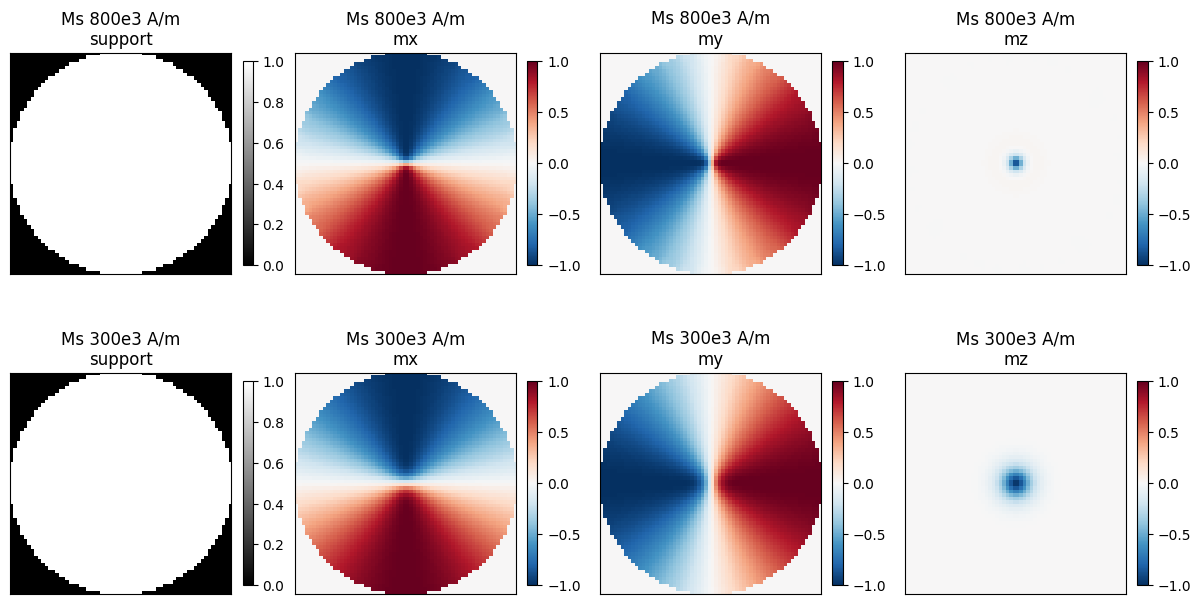

Ms 800e3 A/m: Ms = 8e+05 A/m | elapsed = 17.93 s | mean m = [-0.       0.      -0.00225]
Ms 300e3 A/m: Ms = 3e+05 A/m | elapsed = 16.41 s | mean m = [-0.       0.      -0.01852]


In [6]:
n_cases = len(results)
fig, axs = plt.subplots(n_cases, 4, figsize=(12, 3.2 * n_cases), constrained_layout=True)
if n_cases == 1:
    axs = np.asarray([axs])

for row, (case_name, result) in enumerate(results.items()):
    rho = result["rho"]
    m = result["m"]
    mid = rho.shape[2] // 2
    panels = [
        (rho[:, :, mid].T, "support", "gray", 0.0, 1.0),
        (m[:, :, mid, 0].T, "mx", "RdBu_r", -1.0, 1.0),
        (m[:, :, mid, 1].T, "my", "RdBu_r", -1.0, 1.0),
        (m[:, :, mid, 2].T, "mz", "RdBu_r", -1.0, 1.0),
    ]
    for col, (image, title, cmap, vmin, vmax) in enumerate(panels):
        im = axs[row, col].imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
        axs[row, col].set_title(f"{case_name}\n{title}")
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])
        plt.colorbar(im, ax=axs[row, col], fraction=0.046)
plt.show()

for case_name, result in results.items():
    print(
        f"{case_name}: Ms = {result['Ms_A_per_m']:.3g} A/m | "
        f"elapsed = {result['elapsed_s']:.2f} s | mean m = {result['mean_m']}"
    )

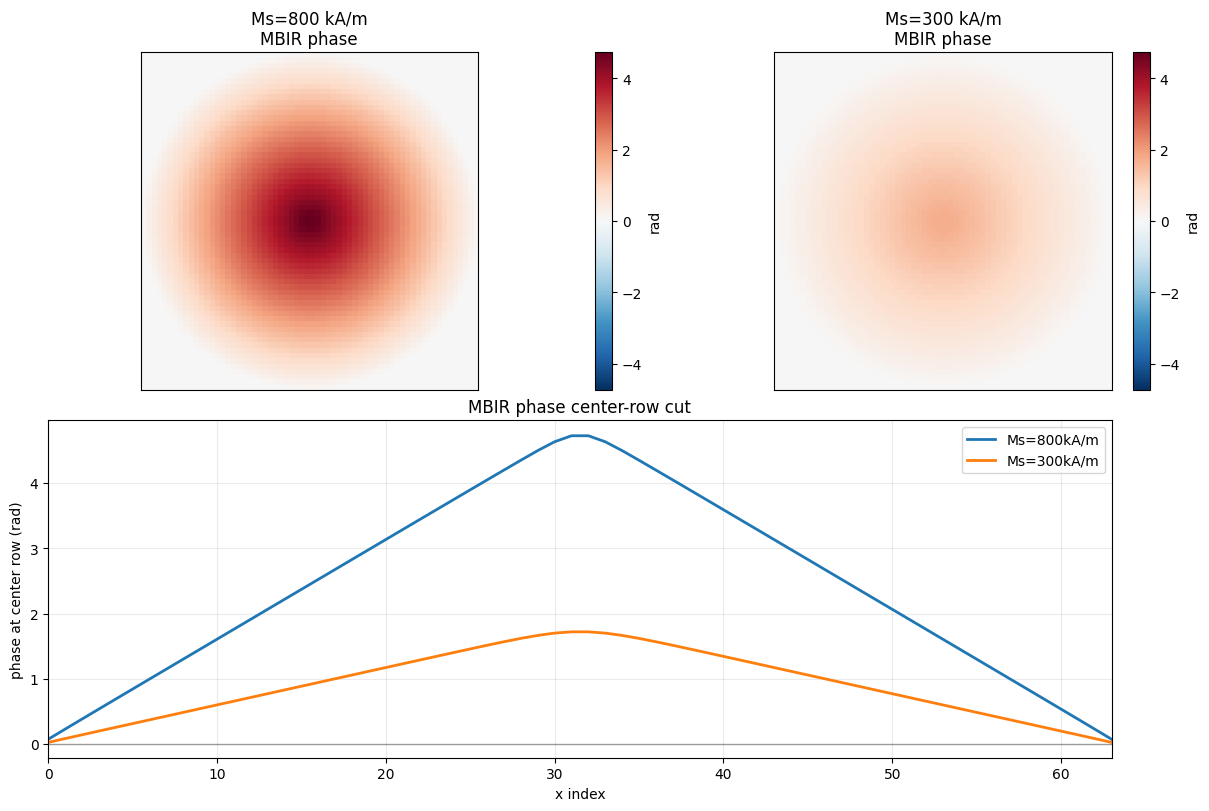

In [7]:
import unxt as u
from libertem_holo.base.mbir import MU_0, build_rdfc_kernel, forward_phase_from_density_and_magnetization


def xyz_to_zyx(values: np.ndarray):
    axes = (2, 1, 0) if values.ndim == 3 else (2, 1, 0, 3)
    return np.transpose(np.asarray(values), axes)


def mbir_phase_image_from_xyz(
    rho_xyz: np.ndarray,
    m_xyz: np.ndarray,
    cellsize_nm_xyz: np.ndarray,
    Ms_A_per_m: float,
):
    pixel_nm = float(cellsize_nm_xyz[0])
    path_step_nm = float(cellsize_nm_xyz[2])
    rho_zyx = xyz_to_zyx(rho_xyz.astype(np.float32))
    field_scale_t = float(np.asarray(MU_0.value)) * float(Ms_A_per_m)
    m_zyx_base = xyz_to_zyx(m_xyz.astype(np.float32)) * field_scale_t
    rdfc_kernel = build_rdfc_kernel((rho_zyx.shape[1], rho_zyx.shape[2]), geometry="disc")

    phase = forward_phase_from_density_and_magnetization(
        rho=rho_zyx,
        magnetization_3d=m_zyx_base,
        pixel_size=u.Quantity(pixel_nm, "nm"),
        projection_step_size=u.Quantity(path_step_nm, "nm"),
        axis="z",
        geometry="disc",
        rdfc_kernel=rdfc_kernel,
        )
    return np.asarray(phase, dtype=np.float32)


def phase_center_row_cut(phase_yx: np.ndarray):
    center_row = phase_yx.shape[0] // 2
    return phase_yx[center_row, :]


phase_results = []
for case_name, result in results.items():
    phase_yx = mbir_phase_image_from_xyz(
        result["rho"],
        result["m"],
        cellsize_nm_xyz,
        result["Ms_A_per_m"],
    )
    result["phase_yx"] = phase_yx
    phase_results.append((case_name, result))

x_index = np.arange(nx)
fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = fig.add_gridspec(2, len(phase_results))

all_phase_values = np.concatenate([result["phase_yx"].ravel() for _, result in phase_results])
phase_lim = max(abs(float(all_phase_values.min())), abs(float(all_phase_values.max())), 1e-12)

for col, (case_name, result) in enumerate(phase_results):
    ax = fig.add_subplot(gs[0, col])
    ms_ka_per_m = result["Ms_A_per_m"] / 1e3
    phase_yx = result["phase_yx"]
    im = ax.imshow(phase_yx, cmap="RdBu_r", vmin=-phase_lim, vmax=phase_lim)
    ax.set_title(f"Ms={ms_ka_per_m:.0f} kA/m\nMBIR phase")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, label="rad")

ax = fig.add_subplot(gs[1, :])
for case_name, result in phase_results:
    profile = phase_center_row_cut(result["phase_yx"])
    ms_ka_per_m = result["Ms_A_per_m"] / 1e3
    ax.plot(x_index, profile, linewidth=2.0, label=f"Ms={ms_ka_per_m:.0f}kA/m")

ax.set_title("MBIR phase center-row cut")
ax.set_xlabel("x index")
ax.set_ylabel("phase at center row (rad)")
ax.set_xlim(0, nx - 1)
ax.axhline(0.0, color="k", linewidth=1.0, alpha=0.35)
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

## Differentiable NeuralMag LLG solver

NeuralMag already owns the Diffrax integration path. For the JAX backend, `nm.LLGSolver(state, parameters=[...])` resolves NeuralMag's registered effective field, builds the Diffrax term internally, and exposes `solve(t, *args)` for differentiable time-dependent optimization.

So the clean path is:

`Msat -> nm.LLGSolver(..., parameters=["material__Ms"]).solve(...) -> NeuralMag node-to-cell projection -> MBIR phase loss`

This still requires NeuralMag's optional JAX LLG dependencies (`diffrax`, `lineax`, and `optimistix`). It also needs JAX x64 enabled before NeuralMag initializes: with SI cell volumes the generated FEM field code divides by very small mass-matrix entries, and float32 underflows in the derivative of that division when differentiating with respect to `Ms`.

For scalar material fits the simplest useful derivative is reverse mode via `jax.value_and_grad(...)`. The objective below uses NeuralMag's public `LLGSolver.solve(...)` API with a fixed Diffrax step size; this keeps the gradient smoother than the adaptive controller while preserving the clean NeuralMag-owned LLG path.


In [ ]:
neuralmag_solver_fit_case_name = "Ms 800e3 A/m"
neuralmag_solver_fit_result = results[neuralmag_solver_fit_case_name]
fit_input_m_cell = np.asarray(neuralmag_solver_fit_result["m0"], dtype=np.float32)

print(f"Fitting target: {neuralmag_solver_fit_case_name}")

# Build a fresh NeuralMag state from the starting magnetization.
# The registered NeuralMag field terms define state.h; LLGSolver resolves that machinery internally.
neuralmag_solver_state = build_skyrmion_llg_state(
    rho_cell,
    fit_input_m_cell,
    Ms_A_per_m=neuralmag_solver_fit_result["Ms_A_per_m"],
)
# Match the scalar LLG damping used to generate the target.
solver_alpha = float(neuralmag_solver_fit_result.get("llg_relax_alpha", material["alpha"]))
neuralmag_solver_state.material.alpha = neuralmag_solver_state.tensor(solver_alpha)

neuralmag_solver = nm.LLGSolver(
    neuralmag_solver_state,
    parameters=["material__Ms"],
    max_steps=llg_max_steps,
)

# The solver returns nodal m. Use NeuralMag's own generated node-to-cell projection
# before passing the field to the MBIR phase model.
solver_node_to_cell = neuralmag_solver_state.resolve(neuralmag_solver_state.m._code.to_cell, ["f"])

solver_dtype = neuralmag_solver_state.dtype
mu0_solver = jnp.asarray(MU_0.value, dtype=solver_dtype)
rho_solver_xyz = jnp.asarray(neuralmag_solver_fit_result["rho"], dtype=solver_dtype)
rho_solver_zyx = jnp.transpose(rho_solver_xyz, (2, 1, 0))
support_solver = rho_solver_xyz > 0.5
rdfc_solver_kernel = build_rdfc_kernel((rho_solver_zyx.shape[1], rho_solver_zyx.shape[2]), geometry="disc", dtype=solver_dtype)
target_phase_solver = jnp.asarray(
    neuralmag_solver_fit_result.get(
        "phase_yx",
        mbir_phase_image_from_xyz(
            neuralmag_solver_fit_result["rho"],
            neuralmag_solver_fit_result["m"],
            cellsize_nm_xyz,
            neuralmag_solver_fit_result["Ms_A_per_m"],
        ),
    ),
    dtype=solver_dtype,
)

llg_fit_time_s = float(neuralmag_solver_fit_result["llg_target_time_s"])
solver_times = neuralmag_solver_state.tensor([0.0, llg_fit_time_s])
print(
    f"LLG fit settings: alpha={solver_alpha:.3g}, "
    f"fixed target time={llg_fit_time_s:.3g}s, "
    f"internal max_steps={llg_max_steps}"
)

msat_min = 2e5
msat_max = 1.0e6


def _bounded_msat(theta):
    return msat_min + (msat_max - msat_min) * jax.nn.sigmoid(theta)


def _ms_solver_field(msat_a_per_m):
    return jnp.ones(rho_solver_xyz.shape, dtype=solver_dtype) * msat_a_per_m


def _normalize_solver_cell_m(m_cell_xyz):
    mask = support_solver.astype(m_cell_xyz.dtype)[..., None]
    norm = jnp.sqrt(jnp.sum(m_cell_xyz * m_cell_xyz, axis=-1, keepdims=True) + jnp.finfo(m_cell_xyz.dtype).eps**2)
    return mask * m_cell_xyz / norm


def _phase_from_solver_node_m(m_node, msat_a_per_m):
    m_cell_xyz = _normalize_solver_cell_m(solver_node_to_cell(m_node))
    m_zyx = jnp.transpose(m_cell_xyz, (2, 1, 0, 3))
    m_zyx = m_zyx * (mu0_solver * msat_a_per_m)
    return forward_phase_from_density_and_magnetization(
        rho=rho_solver_zyx,
        magnetization_3d=m_zyx,
        projection_step_size=u.Quantity(float(cellsize_nm_xyz[2]), "nm"),
        pixel_size=u.Quantity(float(cellsize_nm_xyz[0]), "nm"),
        axis="z",
        geometry="disc",
        rdfc_kernel=rdfc_solver_kernel,
    )


def neuralmag_solver_phase_loss(theta):
    msat = _bounded_msat(theta)
    sol = neuralmag_solver.solve(solver_times, _ms_solver_field(msat))
    phase_pred = _phase_from_solver_node_m(sol.ys[-1], msat)
    residual = phase_pred - target_phase_solver
    loss = 0.5 * jnp.mean(residual * residual)
    aux = {
        "msat": msat,
        "phase_rms": jnp.sqrt(jnp.mean(residual * residual)),
        "phase_pred": phase_pred,
        "m_node_final": sol.ys[-1],
    }
    return loss, aux

2026-04-28 13:00:51 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-04-28 13:00:51 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-28 13:00:51 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-28 13:00:51 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-28 13:00:51 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-28 13:00:51 NeuralMag:INFO [DemagField]: Set up demag tensor


Fitting target: Ms 800e3 A/m
Solver start:   vortex circulation +1, polarization -1


2026-04-28 13:00:53 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-04-28 13:00:53 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-04-28 13:00:53 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-28 13:00:53 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function


LLG fit settings: alpha=1, fixed target time=1.1e-10s, internal max_steps=2048
LLG forward self-check at true Ms: phase RMS=1.61443e-05 rad, loss=1.30318e-10


## LLG versus NeuralMag BB steepest descent

This section keeps both inner physics solvers differentiable and compares the outer `Msat` fit convergence. The LLG branch goes through NeuralMag's `LLGSolver`/Diffrax machinery. The steepest-descent branch now uses NeuralMag's own `EnergyMinimizer`, the same BB/Cayley driver used by the standard-problem demos, via its differentiable fixed-step `solve_fixed(...)` path.

In [ ]:
comparison_outer_steps = 200
comparison_learning_rate = 0.03

# Match NeuralMag's standard-problem BB/Cayley defaults. The convergence
# metric has effective-field units, so 1e3 is already a tight static-relaxation
# tolerance; 1e-3 tends to drive the BB loop into the safety cap.
bb_tol = 1e3
bb_max_iter = 2000
bb_tau_min = 1e-18
bb_tau_max = 1e-4
bb_project_each_step = False

comparison_target_msat = float(neuralmag_solver_fit_result["Ms_A_per_m"])
comparison_target_m_cell = jnp.asarray(neuralmag_solver_fit_result["m"], dtype=solver_dtype)
comparison_input_m_cell = jnp.asarray(fit_input_m_cell, dtype=solver_dtype)
comparison_target_phase = jnp.asarray(target_phase_solver, dtype=solver_dtype)
comparison_input_m_node = jnp.asarray(neuralmag_solver_state.m.tensor, dtype=solver_dtype)
rho_solver_node = jnp.asarray(neuralmag_solver_state.rho.to_node().tensor, dtype=solver_dtype)
support_solver_node = rho_solver_node > 0.5


def _normalize_solver_node_m(m_node_xyz):
    mask = support_solver_node.astype(m_node_xyz.dtype)[..., None]
    norm = jnp.sqrt(jnp.sum(m_node_xyz * m_node_xyz, axis=-1, keepdims=True) + jnp.finfo(m_node_xyz.dtype).eps**2)
    return mask * m_node_xyz / norm


def comparison_phase_from_cell_m(m_cell_xyz, msat_a_per_m):
    m_cell_xyz = _normalize_solver_cell_m(m_cell_xyz)
    m_zyx = jnp.transpose(m_cell_xyz, (2, 1, 0, 3))
    m_zyx = m_zyx * (mu0_solver * msat_a_per_m)
    return forward_phase_from_density_and_magnetization(
        rho=rho_solver_zyx,
        magnetization_3d=m_zyx,
        projection_step_size=u.Quantity(float(cellsize_nm_xyz[2]), "nm"),
        pixel_size=u.Quantity(float(cellsize_nm_xyz[0]), "nm"),
        axis="z",
        geometry="disc",
        rdfc_kernel=rdfc_solver_kernel,
    )


def comparison_cell_m_from_node_m(m_node_xyz):
    return _normalize_solver_cell_m(solver_node_to_cell(_normalize_solver_node_m(m_node_xyz)))


comparison_input_phase = comparison_phase_from_cell_m(comparison_input_m_cell, comparison_target_msat)

# Nodal state for the BB branch, matching NeuralMag's standard-problem BB path.
# The MBIR phase comparison still projects the final nodal magnetization to cells.
sd_state = nm.State(nm.Mesh(tuple(rho_solver_xyz.shape), tuple((cellsize_nm_xyz * 1e-9).tolist())))
sd_rho_np = np.clip(np.asarray(rho_solver_xyz, dtype=np.float64), float(getattr(sd_state, "eps", 1e-12)), 1.0)
sd_state.rho = nm.CellFunction(sd_state, tensor=sd_state.tensor(sd_rho_np, dtype=sd_state.dtype))
sd_state.material.Ms = nm.CellFunction(sd_state).fill(comparison_target_msat)
sd_state.material.A = nm.CellFunction(sd_state).fill(material["A_J_per_m"])
sd_state.material.Di = nm.CellFunction(sd_state).fill(material["Di_J_per_m2"])
sd_state.material.Di_axis = constant_vector_cell_function(sd_state, tuple(rho_solver_xyz.shape), [0.0, 0.0, 1.0])
sd_state.material.Ku = nm.CellFunction(sd_state).fill(material["Ku_J_per_m3"])
sd_state.material.Ku_axis = constant_vector_cell_function(sd_state, tuple(rho_solver_xyz.shape), [0.0, 0.0, 1.0])
sd_state.material.alpha = sd_state.tensor(1.0)
sd_state.m = nm.VectorFunction(sd_state, tensor=sd_state.tensor(np.asarray(neuralmag_solver_state.m.tensor, dtype=np.float64), dtype=sd_state.dtype))
nm.ExchangeField().register(sd_state, "exchange")
nm.DemagField(p=demag_p).register(sd_state, "demag")
nm.InterfaceDMIField().register(sd_state, "idmi")
nm.UniaxialAnisotropyField().register(sd_state, "uaniso")
nm.TotalField("exchange", "demag", "idmi", "uaniso").register(sd_state)

# This is the same NeuralMag BB/Cayley minimizer used by standard-problem-3.
# `parameters=["material__Ms"]` makes the runtime Ms field a differentiable argument.
# The fit path uses convergence-stopped `solve(...)` plus forward-mode JVP for the
# scalar material parameter.
sd_minimizer = nm.EnergyMinimizer(
    sd_state,
    method="alternating",
    update="cayley",
    tau_min=bb_tau_min,
    tau_max=bb_tau_max,
    tol=bb_tol,
    max_iter=bb_max_iter,
    projection=_normalize_solver_node_m if bb_project_each_step else None,
    parameters=["material__Ms"],
)


def _bb_relax_for_fit(msat):
    return sd_minimizer.solve(
        comparison_input_m_node,
        _ms_solver_field(msat),
        tol=bb_tol,
        max_iter=bb_max_iter,
        return_info=True,
    )


def _bb_relax_for_loss(msat):
    return sd_minimizer.solve(
        comparison_input_m_node,
        _ms_solver_field(msat),
        tol=bb_tol,
        max_iter=bb_max_iter,
        return_info=False,
    )


@jax.jit
def steepest_descent_phase_loss(theta):
    msat = _bounded_msat(theta)
    m_final_node, inner_info = _bb_relax_for_fit(msat)
    m_final = comparison_cell_m_from_node_m(m_final_node)
    phase_pred = comparison_phase_from_cell_m(m_final, msat)
    residual = phase_pred - comparison_target_phase
    loss = 0.5 * jnp.mean(residual * residual)
    aux = {
        "msat": msat,
        "phase_rms": jnp.sqrt(jnp.mean(residual * residual)),
        "phase_pred": phase_pred,
        "m_cell_final": m_final,
        "inner_converged": inner_info["converged"],
        "inner_n_iter": inner_info["n_iter"],
        "inner_max_g_last": inner_info["max_g"],
    }
    return loss, aux


@jax.jit
def steepest_descent_loss_only(theta):
    msat = _bounded_msat(theta)
    m_final_node = _bb_relax_for_loss(msat)
    m_final = comparison_cell_m_from_node_m(m_final_node)
    phase_pred = comparison_phase_from_cell_m(m_final, msat)
    residual = phase_pred - comparison_target_phase
    return 0.5 * jnp.mean(residual * residual)


llg_value_and_grad = jax.value_and_grad(neuralmag_solver_phase_loss, has_aux=True)


def llg_loss_grad_aux(theta):
    (loss_value, aux_value), grad_value = llg_value_and_grad(theta)
    return loss_value, grad_value, {
        "msat": aux_value["msat"],
        "phase_rms": aux_value["phase_rms"],
    }


def llg_final_aux(theta):
    _, aux_value = neuralmag_solver_phase_loss(theta)
    return {
        **aux_value,
        "m_cell_final": _normalize_solver_cell_m(solver_node_to_cell(aux_value["m_node_final"])),
    }


llg_loss_grad_aux_jit = jax.jit(llg_loss_grad_aux)
llg_final_aux_jit = jax.jit(llg_final_aux)


def sd_loss_grad_aux(theta):
    # The BB fit has one scalar material parameter, so forward-mode JVP avoids
    # the large reverse-mode tape for the inner magnetization relaxation. Keep
    # the differentiated path scalar-only; full fields and BB diagnostics are
    # computed once by `sd_final_aux_jit` for plotting.
    loss_value, grad_value = jax.jvp(
        steepest_descent_loss_only,
        (theta,),
        (jnp.ones_like(theta),),
    )
    msat = _bounded_msat(theta)
    return loss_value, grad_value, {
        "msat": msat,
        "phase_rms": jnp.sqrt(2.0 * loss_value),
    }


sd_loss_grad_aux_jit = jax.jit(sd_loss_grad_aux)
sd_final_aux_jit = jax.jit(lambda theta: steepest_descent_phase_loss(theta)[1])


def run_scalar_msat_fit(label, step_fn, final_aux_fn, *, outer_steps, learning_rate):
    theta = jnp.asarray(0.0, dtype=solver_dtype)
    optimizer = optax.adam(learning_rate=learning_rate)
    opt_state = optimizer.init(theta)

    compile_start = time.perf_counter()
    warm_loss, _, _ = step_fn(theta)
    warm_loss.block_until_ready()
    compile_elapsed_s = time.perf_counter() - compile_start

    rows = []
    run_start = time.perf_counter()
    for step in range(outer_steps + 1):
        print(f"Optimizer step {step} ...")
        loss_value, grad_value, aux_value = step_fn(theta)
        loss_value.block_until_ready()
        row = {
            "step": step,
            "msat": float(aux_value["msat"]),
            "loss": float(loss_value),
            "phase_rms": float(aux_value["phase_rms"]),
            "grad": float(grad_value),
            "elapsed_s": time.perf_counter() - run_start,
        }
        for key in ("inner_converged", "inner_n_iter", "inner_max_g_last"):
            if key in aux_value:
                value = aux_value[key]
                row[key] = bool(value) if key == "inner_converged" else float(value)
        rows.append(row)
        if step < outer_steps:
            updates, opt_state = optimizer.update(grad_value, opt_state, theta)
            theta = optax.apply_updates(theta, updates)

    final_loss, _, _ = step_fn(theta)
    final_loss.block_until_ready()
    final_aux = final_aux_fn(theta)
    final_aux["phase_rms"].block_until_ready()
    return {
        "label": label,
        "compile_elapsed_s": compile_elapsed_s,
        "history": rows,
        "theta": theta,
        "msat": final_aux["msat"],
        "loss": final_loss,
        "phase_rms": final_aux["phase_rms"],
        "phase_pred": final_aux["phase_pred"],
        "m_cell_final": final_aux["m_cell_final"],
        "aux": final_aux,
    }


method_comparison_results = {}
print(f"Running LLG fit for {comparison_outer_steps} steps with learning rate {comparison_learning_rate} ...")
method_comparison_results["LLG"] = run_scalar_msat_fit(
    "LLG",
    llg_loss_grad_aux_jit,
    llg_final_aux_jit,
    outer_steps=comparison_outer_steps,
    learning_rate=comparison_learning_rate,
)
print(f"Running NeuralMag BB fit for {comparison_outer_steps} steps with learning rate {comparison_learning_rate} ...")
method_comparison_results["NeuralMag BB"] = run_scalar_msat_fit(
    "NeuralMag BB",
    sd_loss_grad_aux_jit,
    sd_final_aux_jit,
    outer_steps=comparison_outer_steps,
    learning_rate=comparison_learning_rate,
)

for label, result in method_comparison_results.items():
    extra = ""
    aux = result.get("aux", {})
    if "inner_n_iter" in aux:
        extra = (
            f", inner steps={int(aux['inner_n_iter'])}, "
            f"inner max_g={float(aux['inner_max_g_last']):.3g}, "
            f"inner converged={bool(aux['inner_converged'])}"
        )
    print(
        f"{label}: final Msat={float(result['msat']):.1f} A/m, "
        f"phase RMS={float(result['phase_rms']):.6g} rad, "
        f"compile/warmup={result['compile_elapsed_s']:.2f}s, "
        f"optimizer={result['history'][-1]['elapsed_s']:.2f}s"
        f"{extra}"
    )

2026-04-28 13:01:08 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-04-28 13:01:08 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-28 13:01:08 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-28 13:01:08 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-28 13:01:08 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-28 13:01:08 NeuralMag:INFO [DemagField]: Set up demag tensor


2026-04-28 13:01:10 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-04-28 13:01:10 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-04-28 13:01:10 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')


Running solver method comparison ...
Comparison start: vortex circulation +1, polarization -1
BB project each step: False
Running LLG fit for 200 steps with learning rate 0.03 ...
Optimizer step 0 ...
Optimizer step 1 ...
Optimizer step 2 ...
Optimizer step 3 ...
Optimizer step 4 ...
Optimizer step 5 ...
Optimizer step 6 ...
Optimizer step 7 ...
Optimizer step 8 ...
Optimizer step 9 ...
Optimizer step 10 ...
Optimizer step 11 ...
Optimizer step 12 ...
Optimizer step 13 ...
Optimizer step 14 ...
Optimizer step 15 ...
Optimizer step 16 ...
Optimizer step 17 ...
Optimizer step 18 ...
Optimizer step 19 ...
Optimizer step 20 ...
Optimizer step 21 ...
Optimizer step 22 ...
Optimizer step 23 ...
Optimizer step 24 ...
Optimizer step 25 ...
Optimizer step 26 ...
Optimizer step 27 ...
Optimizer step 28 ...
Optimizer step 29 ...
Optimizer step 30 ...
Optimizer step 31 ...
Optimizer step 32 ...
Optimizer step 33 ...
Optimizer step 34 ...
Optimizer step 35 ...
Optimizer step 36 ...
Optimizer step 3

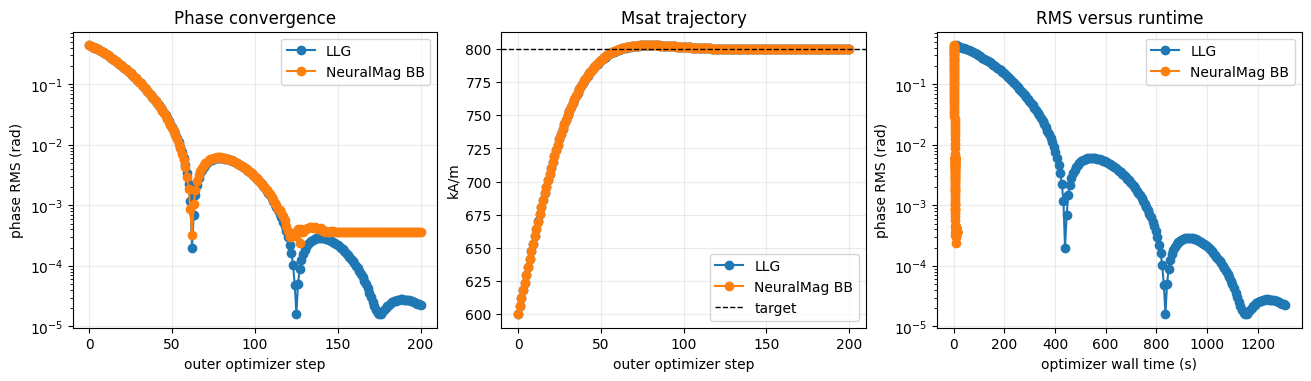

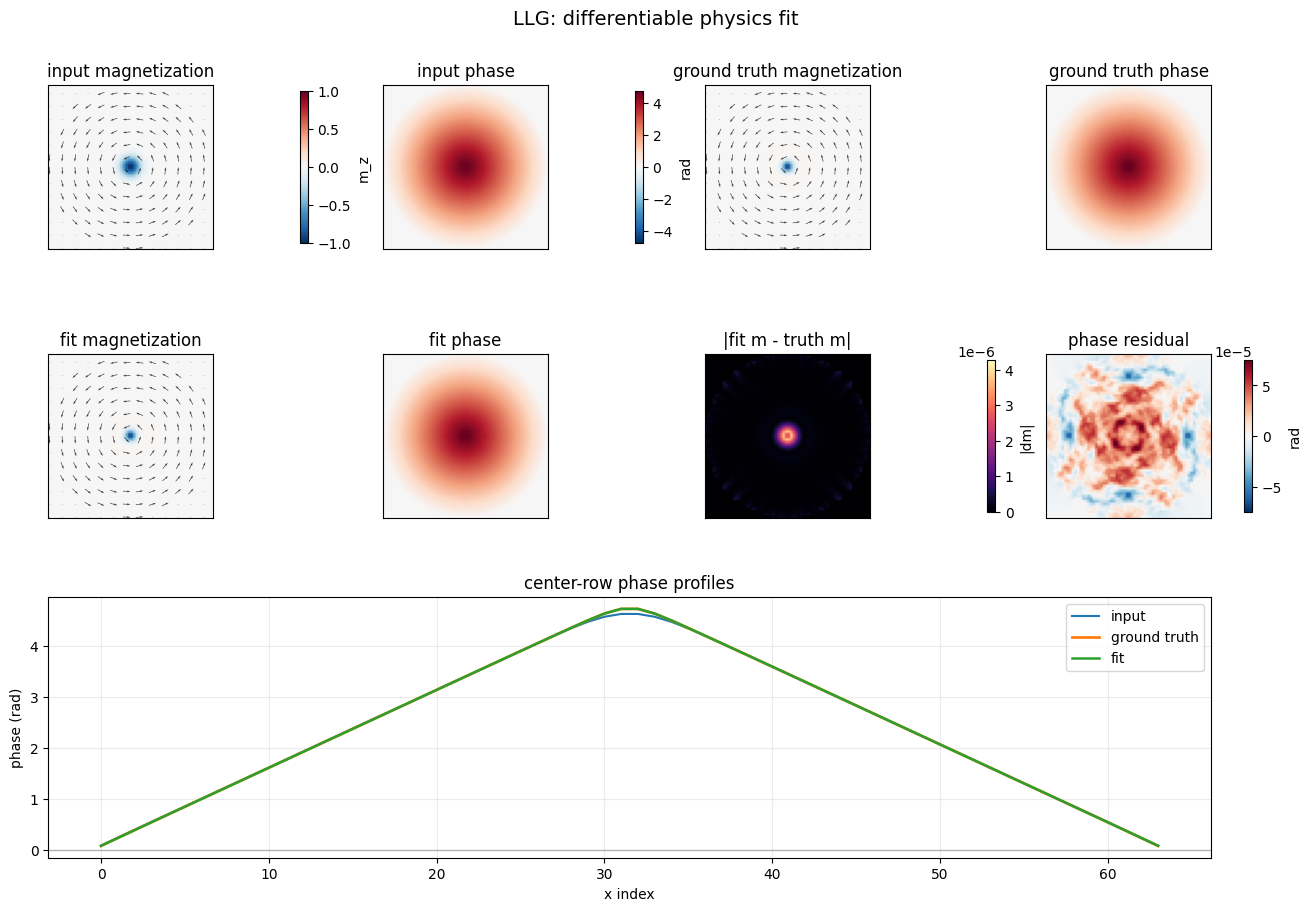

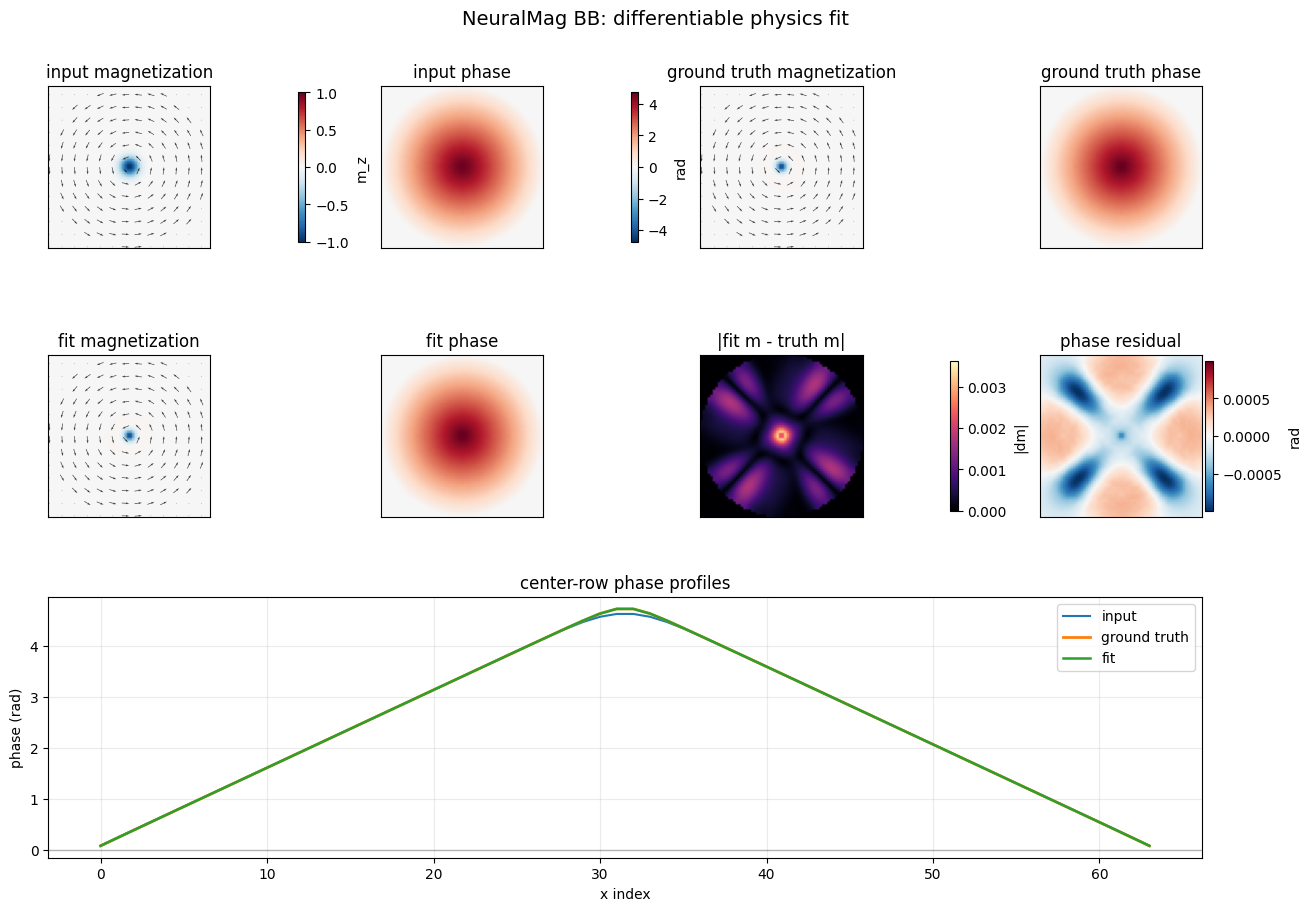

In [ ]:
# Convergence and diagnostic plots for the two differentiable physics paths.

fig, axs = plt.subplots(1, 3, figsize=(13, 3.7), constrained_layout=True)
for label, result in method_comparison_results.items():
    hist = result["history"]
    steps = np.array([row["step"] for row in hist])
    rms = np.array([row["phase_rms"] for row in hist])
    msat = np.array([row["msat"] for row in hist])
    elapsed = np.array([row["elapsed_s"] for row in hist])
    axs[0].semilogy(steps, np.maximum(rms, 1e-30), marker="o", label=label)
    axs[1].plot(steps, msat / 1e3, marker="o", label=label)
    axs[2].semilogy(np.maximum(elapsed, 1e-9), np.maximum(rms, 1e-30), marker="o", label=label)

axs[0].set_title("Phase convergence")
axs[0].set_xlabel("outer optimizer step")
axs[0].set_ylabel("phase RMS (rad)")
axs[0].grid(True, alpha=0.25)
axs[0].legend()

axs[1].axhline(comparison_target_msat / 1e3, color="k", ls="--", lw=1.0, label="target")
axs[1].set_title("Msat trajectory")
axs[1].set_xlabel("outer optimizer step")
axs[1].set_ylabel("kA/m")
axs[1].grid(True, alpha=0.25)
axs[1].legend()

axs[2].set_title("RMS versus runtime")
axs[2].set_xlabel("optimizer wall time (s)")
axs[2].set_ylabel("phase RMS (rad)")
axs[2].grid(True, alpha=0.25)
axs[2].legend()
plt.show()


def _as_np(value):
    return np.asarray(jax.device_get(value), dtype=np.float64)


def _show_m_slice(ax, m_cell, title, *, quiver_step=5):
    mid = m_cell.shape[2] // 2
    mz = m_cell[:, :, mid, 2].T
    im = ax.imshow(mz, cmap="RdBu_r", vmin=-1.0, vmax=1.0)
    x = np.arange(0, m_cell.shape[0], quiver_step)
    y = np.arange(0, m_cell.shape[1], quiver_step)
    xx, yy = np.meshgrid(x, y, indexing="xy")
    mx = m_cell[::quiver_step, ::quiver_step, mid, 0].T
    my = m_cell[::quiver_step, ::quiver_step, mid, 1].T
    ax.quiver(xx, yy, mx, my, color="k", pivot="mid", scale=22, width=0.004, alpha=0.75)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return im


def _show_phase(ax, phase, title, limit):
    im = ax.imshow(phase, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return im


input_m_np = _as_np(comparison_input_m_cell)
target_m_np = _as_np(comparison_target_m_cell)
input_phase_np = _as_np(comparison_input_phase)
target_phase_np = _as_np(comparison_target_phase)

for label, result in method_comparison_results.items():
    fit_m_np = _as_np(result["m_cell_final"])
    fit_phase_np = _as_np(result["phase_pred"])
    phase_resid_np = fit_phase_np - target_phase_np
    m_error_np = np.linalg.norm(fit_m_np - target_m_np, axis=-1)

    phase_lim = max(
        abs(float(input_phase_np.min())),
        abs(float(input_phase_np.max())),
        abs(float(target_phase_np.min())),
        abs(float(target_phase_np.max())),
        abs(float(fit_phase_np.min())),
        abs(float(fit_phase_np.max())),
        1e-12,
    )
    resid_lim = max(abs(float(phase_resid_np.min())), abs(float(phase_resid_np.max())), 1e-12)
    merr_lim = max(float(np.nanmax(m_error_np)), 1e-12)

    fig = plt.figure(figsize=(13, 9), constrained_layout=True)
    gs = fig.add_gridspec(3, 4)
    fig.suptitle(f"{label}: differentiable physics fit", fontsize=14)

    ax = fig.add_subplot(gs[0, 0])
    im_m = _show_m_slice(ax, input_m_np, "input magnetization")
    input_m_ax = ax

    ax = fig.add_subplot(gs[0, 1])
    im_phase_input = _show_phase(ax, input_phase_np, "input phase", phase_lim)
    input_phase_ax = ax

    ax = fig.add_subplot(gs[0, 2])
    _show_m_slice(ax, target_m_np, "ground truth magnetization")

    ax = fig.add_subplot(gs[0, 3])
    _show_phase(ax, target_phase_np, "ground truth phase", phase_lim)

    ax = fig.add_subplot(gs[1, 0])
    _show_m_slice(ax, fit_m_np, "fit magnetization")

    ax = fig.add_subplot(gs[1, 1])
    _show_phase(ax, fit_phase_np, "fit phase", phase_lim)

    ax = fig.add_subplot(gs[1, 2])
    im_err = ax.imshow(m_error_np[:, :, m_error_np.shape[2] // 2].T, cmap="magma", vmin=0.0, vmax=merr_lim)
    ax.set_title("|fit m - truth m|")
    ax.set_xticks([])
    ax.set_yticks([])
    error_ax = ax

    ax = fig.add_subplot(gs[1, 3])
    im_resid = _show_phase(ax, phase_resid_np, "phase residual", resid_lim)
    residual_ax = ax

    ax = fig.add_subplot(gs[2, :])
    x_index = np.arange(target_phase_np.shape[1])
    row = target_phase_np.shape[0] // 2
    ax.plot(x_index, input_phase_np[row], lw=1.5, label="input")
    ax.plot(x_index, target_phase_np[row], lw=2.0, label="ground truth")
    ax.plot(x_index, fit_phase_np[row], lw=1.8, label="fit")
    ax.axhline(0.0, color="k", lw=1.0, alpha=0.25)
    ax.set_title("center-row phase profiles")
    ax.set_xlabel("x index")
    ax.set_ylabel("phase (rad)")
    ax.grid(True, alpha=0.25)
    ax.legend()

    # Attach each colorbar to one contiguous panel to avoid overlap from disjoint axis groups.
    fig.colorbar(im_m, ax=[input_m_ax], fraction=0.046, pad=0.02, label="m_z")
    fig.colorbar(im_phase_input, ax=[input_phase_ax], fraction=0.046, pad=0.02, label="rad")
    fig.colorbar(im_err, ax=[error_ax], fraction=0.046, pad=0.02, label="|dm|")
    fig.colorbar(im_resid, ax=[residual_ax], fraction=0.046, pad=0.02, label="rad")
    plt.show()